In [19]:
import os, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import sys, os, time, warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
sys.path.insert(0, os.path.abspath('../model'))
sys.path.insert(0, os.path.abspath('../parameter_scan'))

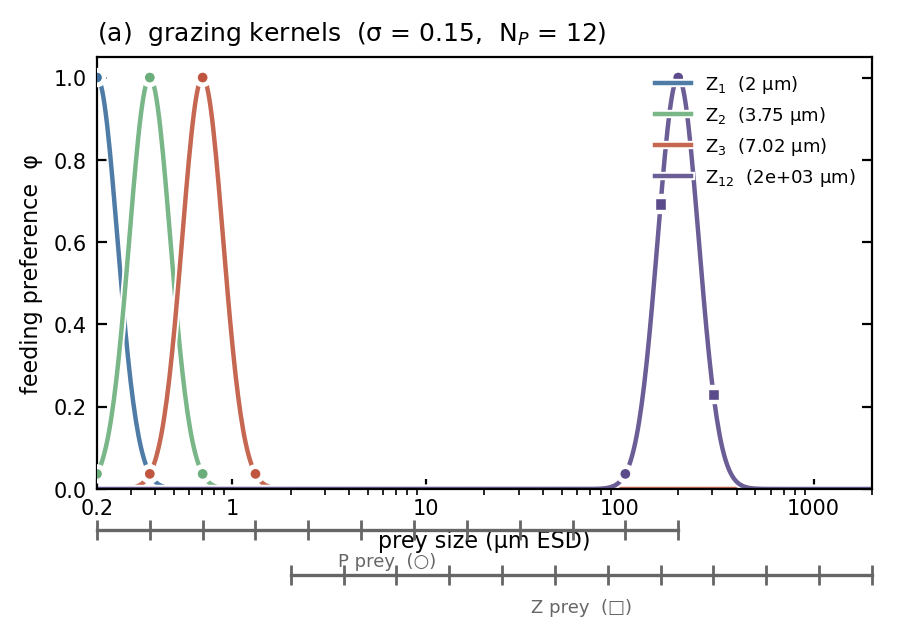

In [3]:
%config InlineBackend.figure_format = 'retina'
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe

HALO = [pe.withStroke(linewidth=3.0, foreground='white')]

# ---- grid knob: vary this -----------------------------------------------------
N_P = 12        # <-- number of phyto size classes (zoo grid is 10x, same count)
# -------------------------------------------------------------------------------

# kernel + grid, verbatim from MS3_Final_Baseline_Model.tex (Eq., line 160)
SIGMA, THETA_OPT = 0.15, 10.0
P_MIN, P_MAX = 0.2, 200.0
phyto_esd = np.logspace(np.log10(P_MIN), np.log10(P_MAX), N_P)
zoo_esd   = THETA_OPT * phyto_esd                       # 2..2000 µm

def kernel(s_pred, prey):                               # φ = exp[-((log10(s_pred/prey)-log10θ)/σ)²]
    d = np.log10(s_pred / prey) - np.log10(THETA_OPT)
    return np.exp(-(d / SIGMA) ** 2)

sel  = [0, 1, 2, N_P - 1]                               # 3 smallest Z + largest Z
cols = ['#3C6E9E', '#6BAE7B', '#C0563F', '#5B4B8A']
MARK_THRESH = 0.02                                      # only mark classes actually grazed

prey = np.logspace(np.log10(P_MIN), np.log10(THETA_OPT * P_MAX), 600)

fig, ax = plt.subplots(figsize=(5.0, 3.6))
fig.subplots_adjust(bottom=0.28)
for i, c in zip(sel, cols):
    ax.plot(prey, kernel(zoo_esd[i], prey), lw=1.6, color=c, alpha=0.9,
            label=f'Z$_{{{i+1}}}$  ({zoo_esd[i]:.3g} µm)', path_effects=HALO, zorder=2)
    phiP = kernel(zoo_esd[i], phyto_esd)
    phiZ = kernel(zoo_esd[i], zoo_esd); phiZ[i] = 0.0   # omni: no self-grazing
    mP, mZ = phiP > MARK_THRESH, phiZ > MARK_THRESH
    ax.plot(phyto_esd[mP], phiP[mP], 'o', ms=4, color=c, mec='white', mew=0.5,
            path_effects=HALO, zorder=3)               # P prey eaten
    ax.plot(zoo_esd[mZ],  phiZ[mZ], 's', ms=4, color=c, mec='white', mew=0.5,
            path_effects=HALO, zorder=3)               # Z prey eaten

# overlap lines with the actual grid classes ticked on them
for grid, span, y, txt in [(phyto_esd, (P_MIN, P_MAX),  -0.10, 'P prey  (○)'),
                           (zoo_esd,   (2.0, 2000.0),  -0.21, 'Z prey  (□)')]:
    ax.plot(span, [y, y], lw=1.2, color='0.4', clip_on=False)
    ax.plot(grid, np.full(len(grid), y), '|', ms=7, color='0.4', clip_on=False)
    ax.text(np.sqrt(span[0]*span[1]), y-0.055, txt, ha='center', va='top',
            fontsize=6.5, color='0.4')

ax.set_xscale('log')
UM = [0.2, 1, 10, 100, 1000]
ax.set_xticks(UM); ax.set_xticklabels(UM)
ax.set_xlim(P_MIN, 2000); ax.set_ylim(0, 1.05)
ax.set_xlabel('prey size (µm ESD)', fontsize=8)
ax.set_ylabel('feeding preference  φ', fontsize=8)
ax.set_title(f'(a)  grazing kernels  (σ = 0.15,  N$_P$ = {N_P})', fontsize=9, loc='left')
ax.tick_params(top=False, right=True, direction='in', labelsize=7.5)
ax.legend(frameon=False, fontsize=6.5, loc='upper right')
plt.show()

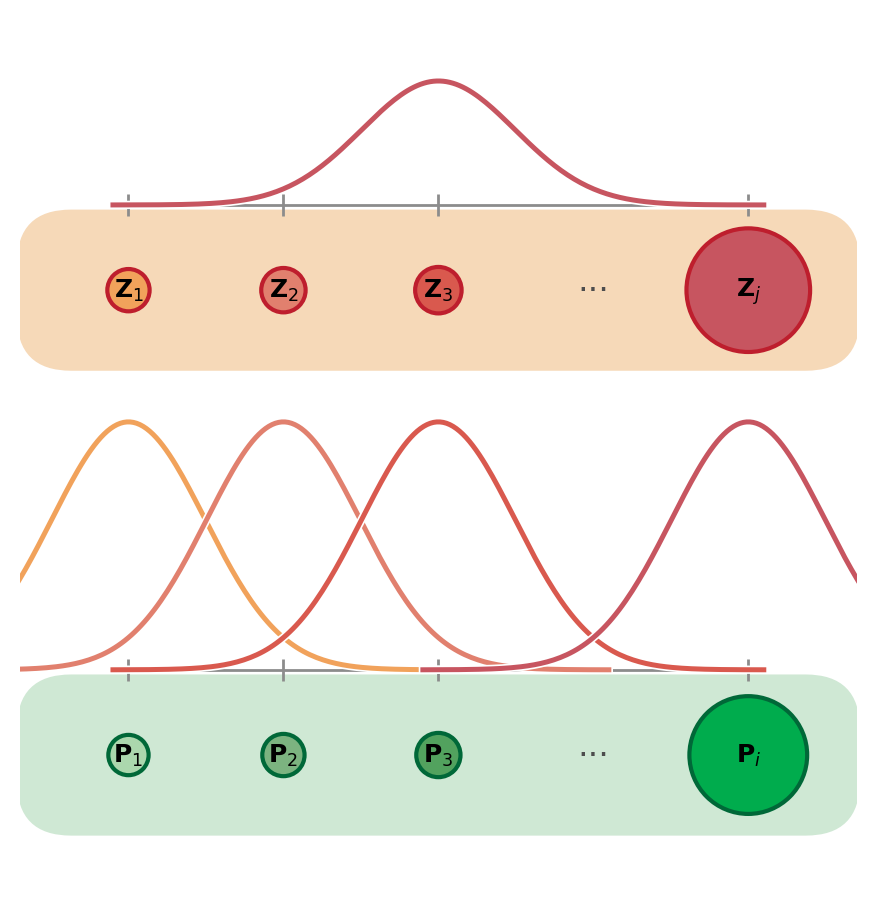

In [7]:
%config InlineBackend.figure_format = 'retina'
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
from matplotlib.patches import FancyBboxPatch
from matplotlib.colors import LinearSegmentedColormap

HALO = [pe.withStroke(linewidth=3.0, foreground='white')]

# ============================ KNOBS ============================
N_P      = 40                 # full model grid resolution (Z grid = 10x, same count)
show_idx = [0, 1, 2, N_P-1]   # which size classes to draw  <-- vary the number here
BELL_W   = 0.70               # schematic kernel half-width, slot units (widen freely)
AMP_P    = 1.60               # P-grazing bell height (band between rows)
AMP_Z    = 0.80               # Z-on-Z omnivory bell height (above Z row)

# exact draft colours (anchors Z1->Zj / P1->Pi); count-independent via ramp interpolation
Z_HEX = ['#F1A25B', '#E1806E', '#D9594E', '#C75560']
P_HEX = ['#ABD7AD', '#7CB380', '#52A25E', '#00AC4D']
Z_EDGE, P_EDGE = '#BE1E2D', '#006838'    # group border colours
# ===============================================================

phyto_esd = np.logspace(np.log10(0.2), np.log10(200.0), N_P)
logmin, logmax = np.log10(0.2), np.log10(200.0)

xs, gaps, x = [], [], 0
for a, idx in enumerate(show_idx):
    if a > 0 and idx - show_idx[a-1] > 1:
        gaps.append(x); x += 1
    xs.append(x); x += 1
xs = np.array(xs); n = len(xs)
x_lo, x_hi = -0.7, xs.max() + 0.7

P_CY, Z_CY, BOXH = 0.0, 3.0, 0.5
P_LINE, Z_LINE = P_CY + BOXH + 0.05, Z_CY + BOXH + 0.05

def radius(idx):
    f = (np.log10(phyto_esd[idx]) - logmin) / (logmax - logmin)
    return 0.13 + 0.25 * f

Zcols = LinearSegmentedColormap.from_list('Zramp', Z_HEX)(np.linspace(0, 1, n))
Pcols = LinearSegmentedColormap.from_list('Pramp', P_HEX)(np.linspace(0, 1, n))

def bell(ax, peak, base, amp, col):
    xx = np.linspace(peak - 3*BELL_W, peak + 3*BELL_W, 200)
    ax.plot(xx, base + amp*np.exp(-((xx-peak)/BELL_W)**2),
            color=col, lw=1.8, path_effects=HALO, zorder=4)

fig, ax = plt.subplots(figsize=(6.0, 4.6))

for cy, fc in [(P_CY, '#CFE8D4'), (Z_CY, '#F6D9B8')]:
    ax.add_patch(FancyBboxPatch((x_lo, cy-BOXH), x_hi-x_lo, 2*BOXH,
                 boxstyle='round,pad=0.02,rounding_size=0.35', fc=fc, ec='none', zorder=1))

for line_y in (P_LINE, Z_LINE):
    ax.plot([xs.min(), xs.max()], [line_y, line_y], color='0.55', lw=1.0, zorder=2)
    ax.plot(xs, np.full(n, line_y), '|', ms=8, color='0.55', zorder=2)

for a, idx in enumerate(show_idx):
    pl = f'{idx+1}' if idx < N_P-1 else 'i'
    zl = f'{idx+1}' if idx < N_P-1 else 'j'
    ax.add_patch(plt.Circle((xs[a], P_CY), radius(idx), fc=Pcols[a], ec=P_EDGE, lw=1.5, zorder=3))
    ax.text(xs[a], P_CY, f'P$_{{{pl}}}$', ha='center', va='center', fontsize=9, fontweight='bold', zorder=5)
    ax.add_patch(plt.Circle((xs[a], Z_CY), radius(idx)*1.05, fc=Zcols[a], ec=Z_EDGE, lw=1.5, zorder=3))
    ax.text(xs[a], Z_CY, f'Z$_{{{zl}}}$', ha='center', va='center', fontsize=9, fontweight='bold', zorder=5)

for gx in gaps:
    ax.text(gx, P_CY, '···', ha='center', va='center', fontsize=12, color='0.3')
    ax.text(gx, Z_CY, '···', ha='center', va='center', fontsize=12, color='0.3')

for a in range(n):
    bell(ax, xs[a], P_LINE, AMP_P, Zcols[a])
bell(ax, xs[n-2], Z_LINE, AMP_Z, Zcols[-1])

ax.set_xlim(x_lo, x_hi); ax.set_ylim(-0.8, Z_LINE + AMP_Z + 0.4)
ax.set_aspect('equal'); ax.axis('off')
plt.tight_layout()
fig.savefig('fig2_kernel_schematic.svg', bbox_inches='tight')
plt.show()

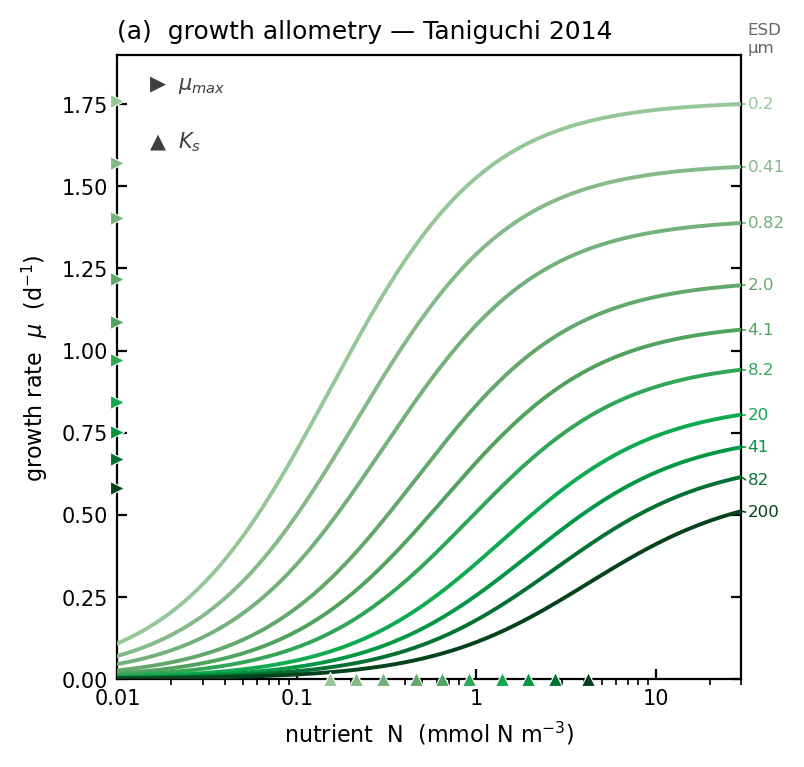

In [18]:
%config InlineBackend.figure_format = 'retina'
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
from matplotlib.colors import LinearSegmentedColormap

HALO = [pe.withStroke(linewidth=3.0, foreground='white')]

# ============================ KNOBS ============================
N_CLASSES = 40
N_SHOW    = 10
N_MIN, N_MAX = 1e-2, 30.0
P_HEX = ['#ABD7AD', '#7CB380', '#52A25E', '#00AC4D', '#04421C']  # +deep terminal for contrast
RAMP_LO = 0.12        # skip the palest end (raise = darker overall)
# ===============================================================

# Taniguchi 2014 growth allometry, verbatim (baseline_r0_setups.py:77-78)
phyto_esd = np.logspace(np.log10(0.2), np.log10(200.0), N_CLASSES)
mu_max = 1.36 * phyto_esd ** (-0.16)
K_s    = 0.33 * phyto_esd ** ( 0.48)

sel   = np.unique(np.linspace(0, N_CLASSES-1, N_SHOW).astype(int))
Pcmap = LinearSegmentedColormap.from_list('Pramp', P_HEX)
logmin, logmax = np.log10(0.2), np.log10(200.0)
def col(s):
    f = (np.log10(s) - logmin) / (logmax - logmin)
    return Pcmap(RAMP_LO + f * (1 - RAMP_LO))

def fmt(v):                                   # plain numbers, never scientific
    if v >= 10: return f'{v:.0f}'
    if v >= 1:  return f'{v:.1f}'
    return f'{v:.2g}'

Nax = np.logspace(np.log10(N_MIN), np.log10(N_MAX), 300)

fig, ax = plt.subplots(figsize=(4.6, 3.9))
ax.set_box_aspect(1)
fig.subplots_adjust(left=0.12, right=0.80, bottom=0.13, top=0.93)

for i in sel:
    c = col(phyto_esd[i])
    ax.plot(Nax, mu_max[i] * Nax / (Nax + K_s[i]), lw=1.4, color=c,  zorder=3)
    ax.plot(N_MIN, mu_max[i], marker='>', ms=5, color=c, mec='white', mew=0.4, clip_on=False, zorder=4)
    ax.plot(K_s[i], 0.0,      marker='^', ms=5, color=c, mec='white', mew=0.4, clip_on=False, zorder=4)

ax.set_xscale('log')
ax.set_xticks([0.01, 0.1, 1, 10]); ax.set_xticklabels([0.01, 0.1, 1, 10])
ax.set_xlim(N_MIN, N_MAX); ax.set_ylim(0, mu_max.max() * 1.08)
ax.set_xlabel('nutrient  N  (mmol N m$^{-3}$)', fontsize=8)
ax.set_ylabel('growth rate  $\\mu$  (d$^{-1}$)', fontsize=8)
ax.set_title('(a)  growth allometry — Taniguchi 2014', fontsize=9, loc='left')
ax.tick_params(top=False, right=True, direction='in', labelsize=7.5)

ax.text(0.05, 0.97, '\u25b6  $\\mu_{max}$', transform=ax.transAxes, fontsize=7.5, va='top', color='0.25')
ax.text(0.05, 0.88, '\u25b2  $K_s$',        transform=ax.transAxes, fontsize=7.5, va='top', color='0.25')

# right-edge size labels (value at N_MAX ≈ μ_max), vertically declutered
y_end = np.array([mu_max[i] * N_MAX / (N_MAX + K_s[i]) for i in sel])
gap   = ax.get_ylim()[1] * 0.052
ylab  = y_end.copy(); last = np.inf
for k in np.argsort(-y_end):
    ylab[k] = min(y_end[k], last - gap); last = ylab[k]
for k, i in enumerate(sel):
    c = col(phyto_esd[i])
    ax.plot([N_MAX, N_MAX*1.05], [y_end[k], ylab[k]], color=c, lw=0.6, clip_on=False, zorder=2)
    ax.text(N_MAX*1.08, ylab[k], fmt(phyto_esd[i]), color=c, fontsize=6,
            va='center', ha='left', clip_on=False)
ax.text(N_MAX*1.08, ax.get_ylim()[1], 'ESD\nµm', fontsize=6, va='bottom', ha='left', color='0.4', clip_on=False)

# fig.savefig('fig2b_panelA_growth.svg', bbox_inches='tight')
plt.show()

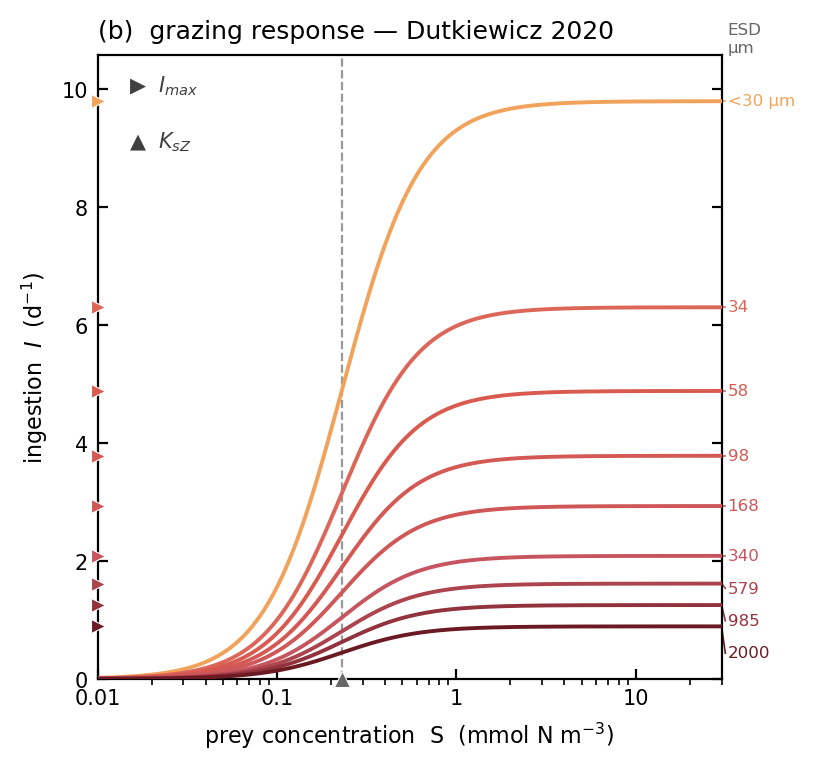

In [14]:
%config InlineBackend.figure_format = 'retina'
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

# ============================ KNOBS ============================
N_CLASSES     = 40
N_SHOW_LARGE  = 8        # individual curves for the >30 µm grazers
S_MIN, S_MAX  = 1e-2, 30.0
K_SZ  = 0.23
Z_HEX = ['#F1A25B', '#E1806E', '#D9594E', '#C75560', '#6B1A24']  # Z1..Zj + deep terminal
RAMP_LO = 0.0
# ===============================================================

phyto_esd = np.logspace(np.log10(0.2), np.log10(200.0), N_CLASSES)
zoo_esd   = 10.0 * phyto_esd
zoo_vol   = (np.pi/6.0) * zoo_esd**3
Imax      = np.where(zoo_esd <= 30.0, 9.8, 30.9 * zoo_vol**(-0.16))   # baseline_r0_setups.py:82-83

Zcmap = LinearSegmentedColormap.from_list('Zramp', Z_HEX)
zlog0, zlog1 = np.log10(2.0), np.log10(2000.0)
def col(s):
    f = (np.log10(s) - zlog0) / (zlog1 - zlog0)
    return Zcmap(RAMP_LO + f*(1-RAMP_LO))
def fmt(v):
    if v >= 10: return f'{v:.0f}'
    if v >= 1:  return f'{v:.1f}'
    return f'{v:.2g}'

small = np.where(zoo_esd <= 30.0)[0]                                   # shared I_max = 9.8
large = np.where(zoo_esd >  30.0)[0]
sel_l = np.unique(np.linspace(large[0], large[-1], N_SHOW_LARGE).astype(int))
Sax   = np.logspace(np.log10(S_MIN), np.log10(S_MAX), 300)
TIII  = lambda Im: Im * Sax**2 / (Sax**2 + K_SZ**2)

fig, ax = plt.subplots(figsize=(4.6, 3.9))
ax.set_box_aspect(1)
fig.subplots_adjust(left=0.12, right=0.80, bottom=0.13, top=0.93)

# one orange line for the whole <30 µm group
c_small = col(zoo_esd[small[0]])
ax.plot(Sax, TIII(9.8), lw=1.4, color=c_small, zorder=3)
ax.plot(S_MIN, 9.8, marker='>', ms=5, color=c_small, mec='white', mew=0.4, clip_on=False, zorder=4)
# individual curves for >30 µm
for i in sel_l:
    c = col(zoo_esd[i])
    ax.plot(Sax, TIII(Imax[i]), lw=1.4, color=c, zorder=3)
    ax.plot(S_MIN, Imax[i], marker='>', ms=5, color=c, mec='white', mew=0.4, clip_on=False, zorder=4)

ax.axvline(K_SZ, color='0.6', ls='--', lw=0.8, zorder=1)
ax.plot(K_SZ, 0.0, marker='^', ms=6, color='0.4', mec='white', mew=0.4, clip_on=False, zorder=4)

ax.set_xscale('log'); ax.set_xticks([0.01,0.1,1,10]); ax.set_xticklabels([0.01,0.1,1,10])
ax.set_xlim(S_MIN, S_MAX); ax.set_ylim(0, Imax.max()*1.08)
ax.set_xlabel('prey concentration  S  (mmol N m$^{-3}$)', fontsize=8)
ax.set_ylabel('ingestion  $I$  (d$^{-1}$)', fontsize=8)
ax.set_title('(b)  grazing response — Dutkiewicz 2020', fontsize=9, loc='left')
ax.tick_params(top=False, right=True, direction='in', labelsize=7.5)
ax.text(0.05, 0.97, '\u25b6  $I_{max}$', transform=ax.transAxes, fontsize=7.5, va='top', color='0.25')
ax.text(0.05, 0.88, '\u25b2  $K_{sZ}$',  transform=ax.transAxes, fontsize=7.5, va='top', color='0.25')

# right-edge labels: "<30 µm" group line + individual large classes, decluttered
items = [(9.8*S_MAX**2/(S_MAX**2+K_SZ**2), '<30 µm', c_small)]
for i in sel_l:
    items.append((Imax[i]*S_MAX**2/(S_MAX**2+K_SZ**2), fmt(zoo_esd[i]), col(zoo_esd[i])))
y_raw = np.array([it[0] for it in items]); gap = ax.get_ylim()[1]*0.052
ylab = y_raw.copy(); last = np.inf
for k in np.argsort(-y_raw):
    ylab[k] = min(y_raw[k], last-gap); last = ylab[k]
for k,(yr, txt, c) in enumerate(items):
    ax.plot([S_MAX, S_MAX*1.05], [yr, ylab[k]], color=c, lw=0.6, clip_on=False, zorder=2)
    ax.text(S_MAX*1.08, ylab[k], txt, color=c, fontsize=6, va='center', ha='left', clip_on=False)
ax.text(S_MAX*1.08, ax.get_ylim()[1], 'ESD\nµm', fontsize=6, va='bottom', ha='left', color='0.4', clip_on=False)

# fig.savefig('fig2b_panelB_grazing.svg', bbox_inches='tight')
plt.show()

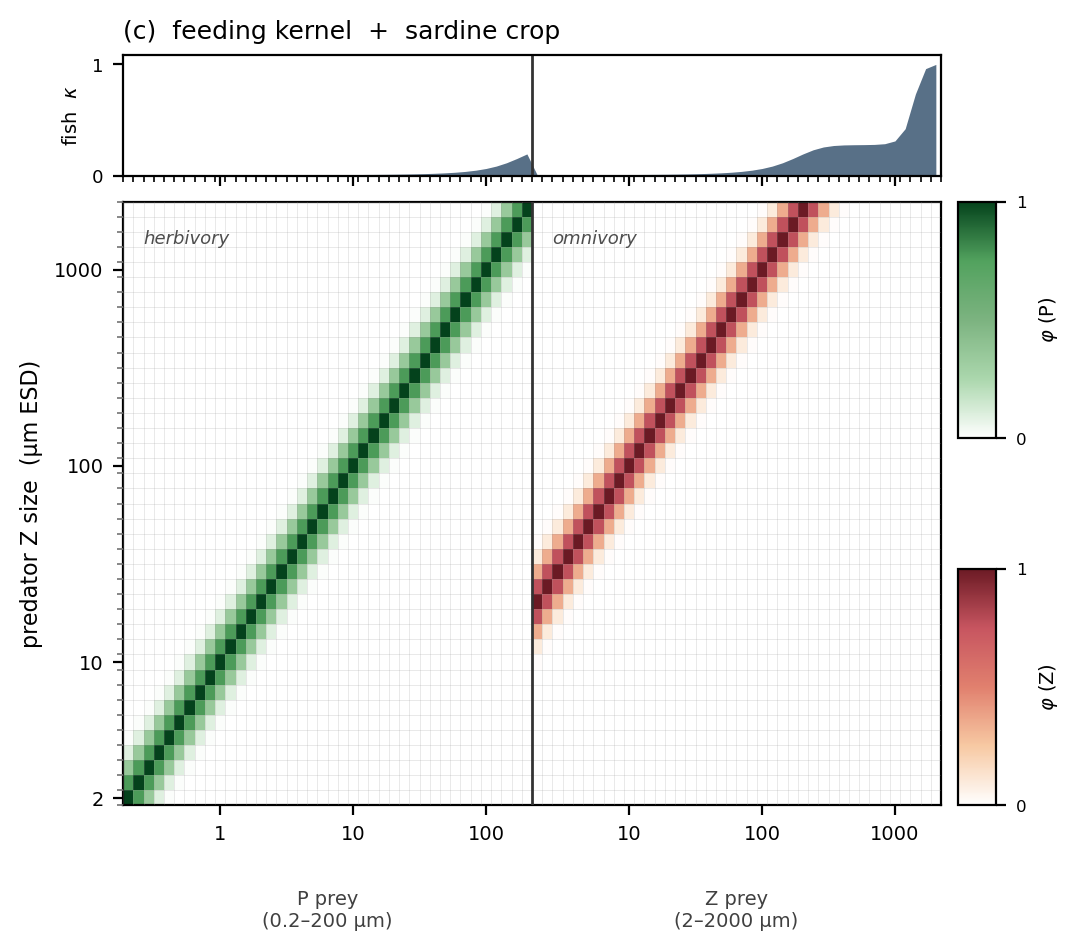

In [22]:
%config InlineBackend.figure_format = 'retina'
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from baseline_r0_comps import compute_grazing_kernel, compute_fish_kernel_vdl_joint

# ============================ KNOBS ============================
N_CLASSES = 40
THETA_OPT, SIGMA = 10.0, 0.15
FISH_COL = '#46607A'
# ===============================================================

phyto_esd = np.logspace(np.log10(0.2), np.log10(200.0), N_CLASSES)
zoo_esd   = 10.0 * phyto_esd
n_P, n_Z  = len(phyto_esd), len(zoo_esd)
n_prey    = n_P + n_Z

phiPZ = compute_grazing_kernel(phyto_esd, zoo_esd, mode='omni',
                               theta_opt=THETA_OPT, sigma_log=SIGMA, convention='mattern')
F_P, F_Z = compute_fish_kernel_vdl_joint(phyto_esd, zoo_esd)
fish = np.concatenate([F_P, F_Z])

cmap_P = LinearSegmentedColormap.from_list('phiP', ['white', '#ABD7AD', '#7CB380', '#52A25E', '#04421C'])
cmap_Z = LinearSegmentedColormap.from_list('phiZ', ['white', '#F7C9A3', '#E1806E', '#C75560', '#6B1A24'])
def idx_at(arr, t): return int(np.argmin(np.abs(np.log10(arr) - np.log10(t))))

fig = plt.figure(figsize=(5.9, 5.0))
gs  = fig.add_gridspec(2, 2, width_ratios=[30, 1.4], height_ratios=[1, 5],
                       hspace=0.07, wspace=0.04, left=0.12, right=0.86, top=0.92, bottom=0.17)
axf = fig.add_subplot(gs[0, 0])
axh = fig.add_subplot(gs[1, 0], sharex=axf)

# --- heatmap: P block green, Z block red, shared φ scale ---
pmP = axh.pcolormesh(np.arange(n_P+1),        np.arange(n_Z+1), phiPZ.T[:, :n_P], cmap=cmap_P, vmin=0, vmax=1)
pmZ = axh.pcolormesh(np.arange(n_P, n_prey+1), np.arange(n_Z+1), phiPZ.T[:, n_P:], cmap=cmap_Z, vmin=0, vmax=1)
axh.set_xlim(0, n_prey); axh.set_ylim(0, n_Z)
xt = [idx_at(phyto_esd,t)+0.5 for t in (1,10,100)] + [n_P+idx_at(zoo_esd,t)+0.5 for t in (10,100,1000)]
axh.set_xticks(xt); axh.set_xticklabels(['1','10','100','10','100','1000'], fontsize=6.5)
axh.set_yticks([idx_at(zoo_esd,t)+0.5 for t in (2,10,100,1000)])
axh.set_yticklabels(['2','10','100','1000'], fontsize=7)
axh.set_yticks(np.arange(n_Z+1), minor=True)
axh.set_xticks(np.arange(n_prey+1), minor=True)
axh.tick_params(axis='y', which='minor', length=2.2, color='0.45', right=False)
axh.tick_params(axis='x', which='minor', length=0)
axh.set_axisbelow(False)
axh.grid(which='minor', color='0.6', lw=0.25, alpha=0.3)
axh.axvline(n_P, color='0.2', lw=1.0, zorder=6)
axh.set_ylabel('predator Z size  (µm ESD)', fontsize=8)
axh.tick_params(which='major', top=False, right=False, direction='out', labelsize=7)
axh.text(n_P/2, -0.14*n_Z, 'P prey\n(0.2–200 µm)', ha='center', va='top', fontsize=7, color='0.25', clip_on=False)
axh.text(n_P+n_Z/2, -0.14*n_Z, 'Z prey\n(2–2000 µm)', ha='center', va='top', fontsize=7, color='0.25', clip_on=False)
axh.text(2, 0.93*n_Z, 'herbivory', fontsize=6.5, style='italic', color='0.3', zorder=7)
axh.text(n_P+2, 0.93*n_Z, 'omnivory', fontsize=6.5, style='italic', color='0.3', zorder=7)

# --- fish marginal ---
xc = np.arange(n_prey)+0.5
axf.fill_between(xc, 0, fish, color=FISH_COL, alpha=0.9, lw=0)
axf.axvline(n_P, color='0.2', lw=1.0)
axf.set_ylim(0, 1.08); axf.set_yticks([0,1]); axf.set_yticklabels(['0','1'], fontsize=6.5)
axf.set_ylabel('fish  $\\kappa$', fontsize=7)
axf.tick_params(labelbottom=False, top=False, right=False)
axf.set_title('(c)  feeding kernel  +  sardine crop', fontsize=9, loc='left')

# --- two stacked colourbars (P green / Z red), shared 0–1 scale ---
cgs = gs[1, 1].subgridspec(2, 1, hspace=0.55)
cbP = fig.colorbar(pmP, cax=fig.add_subplot(cgs[0])); cbP.set_label('$\\varphi$ (P)', fontsize=7)
cbZ = fig.colorbar(pmZ, cax=fig.add_subplot(cgs[1])); cbZ.set_label('$\\varphi$ (Z)', fontsize=7)
for cb in (cbP, cbZ):
    cb.set_ticks([0, 1]); cb.ax.tick_params(labelsize=6)

# fig.savefig('fig2b_panelC_kernel_fish.svg', bbox_inches='tight')
plt.show()

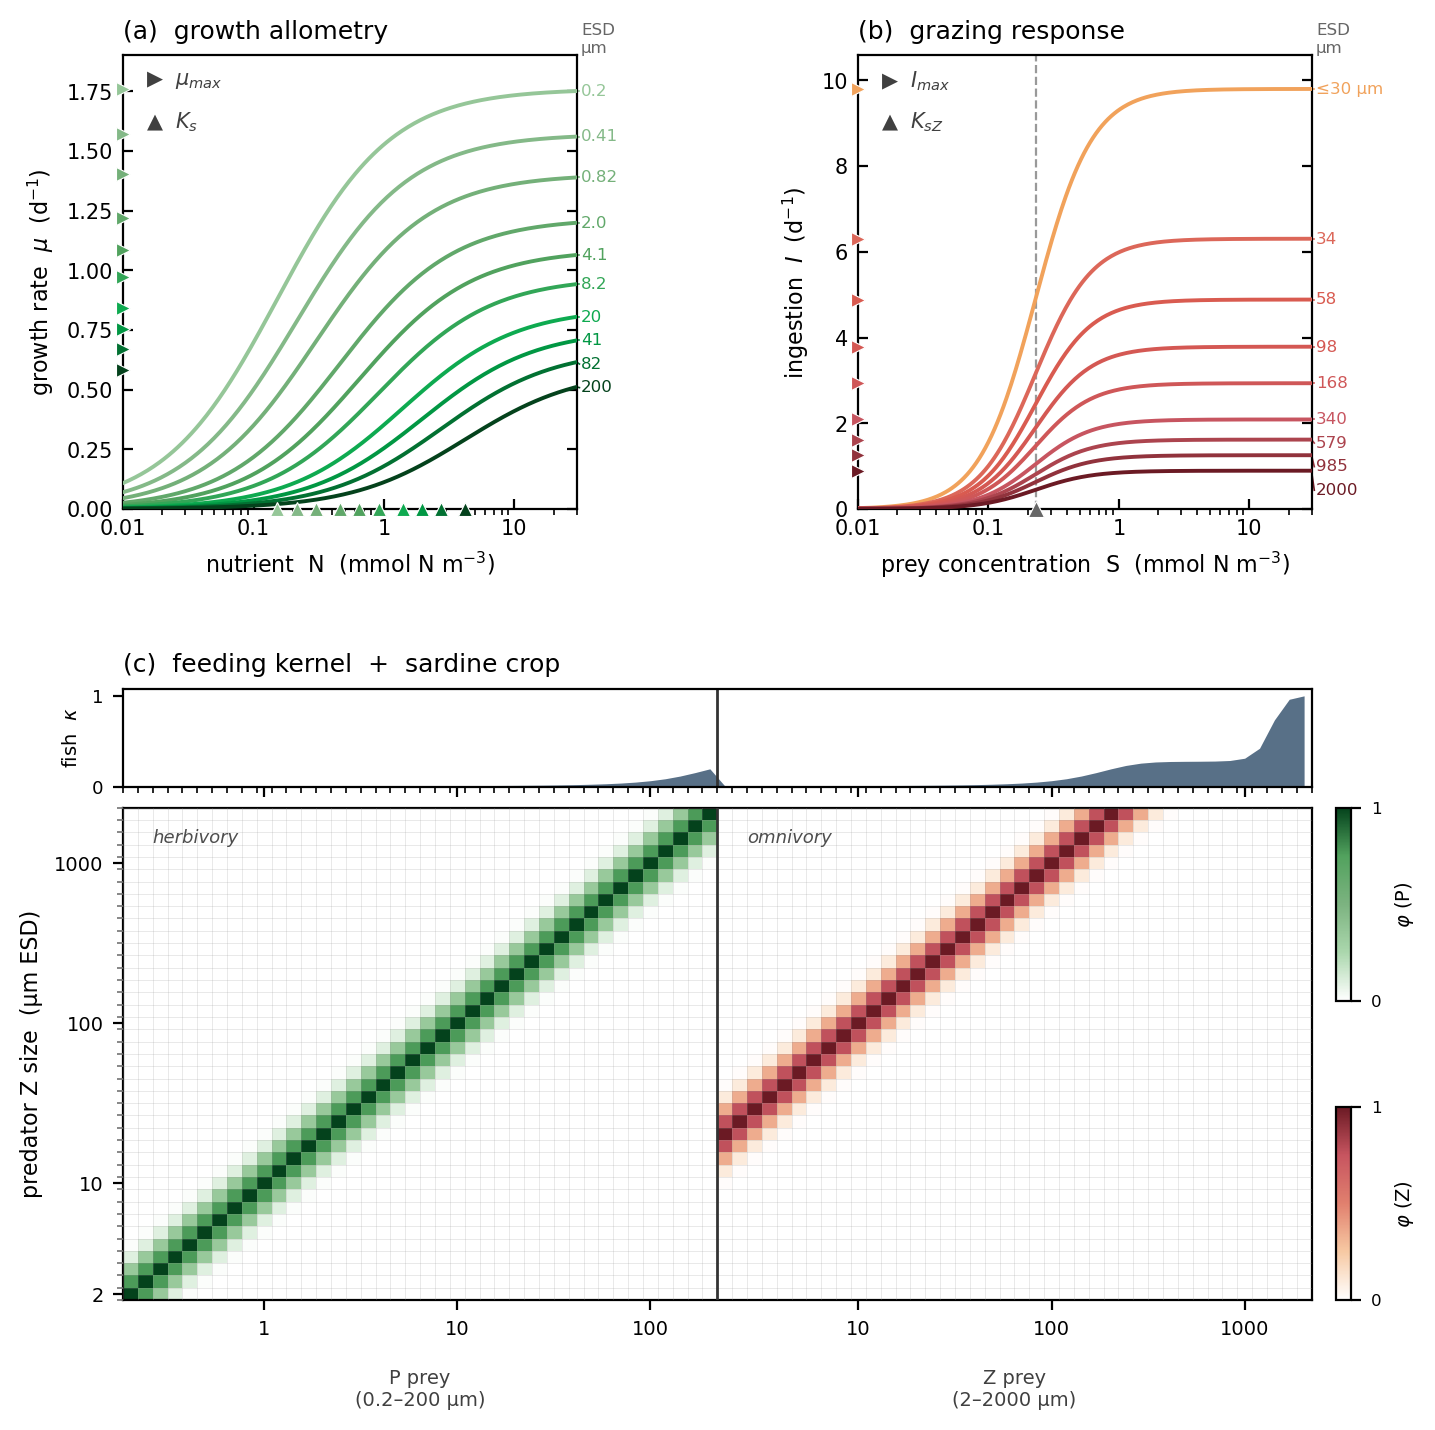

In [31]:
%config InlineBackend.figure_format = 'retina'
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from baseline_r0_comps import compute_grazing_kernel, compute_fish_kernel_vdl_joint

# ---------------- shared grid + palettes ----------------
N_CLASSES = 40
phyto_esd = np.logspace(np.log10(0.2), np.log10(200.0), N_CLASSES)
zoo_esd   = 10.0 * phyto_esd
n_P = n_Z = N_CLASSES; n_prey = n_P + n_Z

P_HEX = ['#ABD7AD', '#7CB380', '#52A25E', '#00AC4D', '#04421C']
Z_HEX = ['#F1A25B', '#E1806E', '#D9594E', '#C75560', '#6B1A24']
Pcmap = LinearSegmentedColormap.from_list('P', P_HEX)
Zcmap = LinearSegmentedColormap.from_list('Z', Z_HEX)
plog0, plog1 = np.log10(0.2), np.log10(200.0)
zlog0, zlog1 = np.log10(2.0), np.log10(2000.0)
def colP(s, lo=0.12): f=(np.log10(s)-plog0)/(plog1-plog0); return Pcmap(lo+f*(1-lo))
def colZ(s, lo=0.0):  f=(np.log10(s)-zlog0)/(zlog1-zlog0); return Zcmap(lo+f*(1-lo))
def fmt(v):
    if v>=10: return f'{v:.0f}'
    if v>=1:  return f'{v:.1f}'
    return f'{v:.2g}'
cmap_phiP = LinearSegmentedColormap.from_list('phiP', ['white','#ABD7AD','#7CB380','#52A25E','#04421C'])
cmap_phiZ = LinearSegmentedColormap.from_list('phiZ', ['white','#F7C9A3','#E1806E','#C75560','#6B1A24'])
def idx_at(arr,t): return int(np.argmin(np.abs(np.log10(arr)-np.log10(t))))

# ---------------- (a) growth ----------------
def draw_a(ax):
    N_SHOW=10; N_MIN,N_MAX=1e-2,30.0
    mu_max=1.36*phyto_esd**(-0.16); K_s=0.33*phyto_esd**0.48
    sel=np.unique(np.linspace(0,N_CLASSES-1,N_SHOW).astype(int))
    Nax=np.logspace(np.log10(N_MIN),np.log10(N_MAX),300); ax.set_box_aspect(1)
    for i in sel:
        c=colP(phyto_esd[i])
        ax.plot(Nax, mu_max[i]*Nax/(Nax+K_s[i]), lw=1.4, color=c, zorder=3)
        ax.plot(N_MIN, mu_max[i], marker='>', ms=5, color=c, mec='white', mew=0.4, clip_on=False, zorder=4)
        ax.plot(K_s[i], 0.0, marker='^', ms=5, color=c, mec='white', mew=0.4, clip_on=False, zorder=4)
    ax.set_xscale('log'); ax.set_xticks([0.01,0.1,1,10]); ax.set_xticklabels([0.01,0.1,1,10])
    ax.set_xlim(N_MIN,N_MAX); ax.set_ylim(0, mu_max.max()*1.08)
    ax.set_xlabel('nutrient  N  (mmol N m$^{-3}$)', fontsize=8)
    ax.set_ylabel('growth rate  $\\mu$  (d$^{-1}$)', fontsize=8)
    ax.set_title('(a)  growth allometry', fontsize=9, loc='left')
    ax.tick_params(top=False, right=True, direction='in', labelsize=7.5)
    ax.text(0.05,0.97,'\u25b6  $\\mu_{max}$',transform=ax.transAxes,fontsize=7.5,va='top',color='0.25')
    ax.text(0.05,0.88,'\u25b2  $K_s$',transform=ax.transAxes,fontsize=7.5,va='top',color='0.25')
    y_end=np.array([mu_max[i]*N_MAX/(N_MAX+K_s[i]) for i in sel])
    gap=ax.get_ylim()[1]*0.052; ylab=y_end.copy(); last=np.inf
    for k in np.argsort(-y_end): ylab[k]=min(y_end[k],last-gap); last=ylab[k]
    for k,i in enumerate(sel):
        c=colP(phyto_esd[i])
        ax.plot([N_MAX,N_MAX*1.05],[y_end[k],ylab[k]],color=c,lw=0.6,clip_on=False,zorder=2)
        ax.text(N_MAX*1.08, ylab[k], fmt(phyto_esd[i]), color=c, fontsize=6, va='center', ha='left', clip_on=False)
    ax.text(N_MAX*1.08, ax.get_ylim()[1], 'ESD\nµm', fontsize=6, va='bottom', ha='left', color='0.4', clip_on=False)

# ---------------- (b) grazing ----------------
def draw_b(ax):
    N_SHOW_LARGE=8; S_MIN,S_MAX=1e-2,30.0; K_SZ=0.23
    Imax=np.where(zoo_esd<=30.0, 9.8, 30.9*((np.pi/6)*zoo_esd**3)**(-0.16))
    small=np.where(zoo_esd<=30.0)[0]; large=np.where(zoo_esd>30.0)[0]
    sel_l=np.unique(np.linspace(large[0],large[-1],N_SHOW_LARGE).astype(int))
    Sax=np.logspace(np.log10(S_MIN),np.log10(S_MAX),300); TIII=lambda Im: Im*Sax**2/(Sax**2+K_SZ**2)
    ax.set_box_aspect(1); c_small=colZ(zoo_esd[small[0]])
    ax.plot(Sax, TIII(9.8), lw=1.4, color=c_small, zorder=3)
    ax.plot(S_MIN, 9.8, marker='>', ms=5, color=c_small, mec='white', mew=0.4, clip_on=False, zorder=4)
    for i in sel_l:
        c=colZ(zoo_esd[i])
        ax.plot(Sax, TIII(Imax[i]), lw=1.4, color=c, zorder=3)
        ax.plot(S_MIN, Imax[i], marker='>', ms=5, color=c, mec='white', mew=0.4, clip_on=False, zorder=4)
    ax.axvline(K_SZ, color='0.6', ls='--', lw=0.8, zorder=1)
    ax.plot(K_SZ, 0.0, marker='^', ms=6, color='0.4', mec='white', mew=0.4, clip_on=False, zorder=4)
    ax.set_xscale('log'); ax.set_xticks([0.01,0.1,1,10]); ax.set_xticklabels([0.01,0.1,1,10])
    ax.set_xlim(S_MIN,S_MAX); ax.set_ylim(0, Imax.max()*1.08)
    ax.set_xlabel('prey concentration  S  (mmol N m$^{-3}$)', fontsize=8)
    ax.set_ylabel('ingestion  $I$  (d$^{-1}$)', fontsize=8)
    ax.set_title('(b)  grazing response ', fontsize=9, loc='left')
    ax.tick_params(top=False, right=True, direction='in', labelsize=7.5)
    ax.text(0.05,0.97,'\u25b6  $I_{max}$',transform=ax.transAxes,fontsize=7.5,va='top',color='0.25')
    ax.text(0.05,0.88,'\u25b2  $K_{sZ}$',transform=ax.transAxes,fontsize=7.5,va='top',color='0.25')
    items=[(9.8*S_MAX**2/(S_MAX**2+K_SZ**2),'≤30 µm',c_small)]
    for i in sel_l: items.append((Imax[i]*S_MAX**2/(S_MAX**2+K_SZ**2), fmt(zoo_esd[i]), colZ(zoo_esd[i])))
    y_raw=np.array([it[0] for it in items]); gap=ax.get_ylim()[1]*0.052; ylab=y_raw.copy(); last=np.inf
    for k in np.argsort(-y_raw): ylab[k]=min(y_raw[k],last-gap); last=ylab[k]
    for k,(yr,txt,c) in enumerate(items):
        ax.plot([S_MAX,S_MAX*1.05],[yr,ylab[k]],color=c,lw=0.6,clip_on=False,zorder=2)
        ax.text(S_MAX*1.08, ylab[k], txt, color=c, fontsize=6, va='center', ha='left', clip_on=False)
    ax.text(S_MAX*1.08, ax.get_ylim()[1], 'ESD\nµm', fontsize=6, va='bottom', ha='left', color='0.4', clip_on=False)

# ---------------- (c) kernel + fish ----------------
def draw_c(axf, axh, caxP, caxZ):
    phiPZ=compute_grazing_kernel(phyto_esd, zoo_esd, mode='omni', theta_opt=10.0, sigma_log=0.15, convention='mattern')
    F_P,F_Z=compute_fish_kernel_vdl_joint(phyto_esd, zoo_esd); fish=np.concatenate([F_P,F_Z])
    pmP=axh.pcolormesh(np.arange(n_P+1), np.arange(n_Z+1), phiPZ.T[:,:n_P], cmap=cmap_phiP, vmin=0, vmax=1)
    pmZ=axh.pcolormesh(np.arange(n_P,n_prey+1), np.arange(n_Z+1), phiPZ.T[:,n_P:], cmap=cmap_phiZ, vmin=0, vmax=1)
    axh.set_xlim(0,n_prey); axh.set_ylim(0,n_Z)
    xt=[idx_at(phyto_esd,t)+0.5 for t in (1,10,100)]+[n_P+idx_at(zoo_esd,t)+0.5 for t in (10,100,1000)]
    axh.set_xticks(xt); axh.set_xticklabels(['1','10','100','10','100','1000'], fontsize=6.5)
    axh.set_yticks([idx_at(zoo_esd,t)+0.5 for t in (2,10,100,1000)]); axh.set_yticklabels(['2','10','100','1000'],fontsize=7)
    axh.set_yticks(np.arange(n_Z+1), minor=True); axh.set_xticks(np.arange(n_prey+1), minor=True)
    axh.tick_params(axis='y', which='minor', length=2.2, color='0.45', right=False)
    axh.tick_params(axis='x', which='minor', length=0)
    axh.set_axisbelow(False); axh.grid(which='minor', color='0.6', lw=0.25, alpha=0.3)
    axh.axvline(n_P, color='0.2', lw=1.0, zorder=6)
    axh.set_ylabel('predator Z size  (µm ESD)', fontsize=8)
    axh.tick_params(which='major', top=False, right=False, direction='out', labelsize=7)
    axh.text(n_P/2, -0.14*n_Z, 'P prey\n(0.2–200 µm)', ha='center', va='top', fontsize=7, color='0.25', clip_on=False)
    axh.text(n_P+n_Z/2, -0.14*n_Z, 'Z prey\n(2–2000 µm)', ha='center', va='top', fontsize=7, color='0.25', clip_on=False)
    axh.text(2, 0.93*n_Z, 'herbivory', fontsize=6.5, style='italic', color='0.3', zorder=7)
    axh.text(n_P+2, 0.93*n_Z, 'omnivory', fontsize=6.5, style='italic', color='0.3', zorder=7)
    xc=np.arange(n_prey)+0.5
    axf.fill_between(xc, 0, fish, color='#46607A', alpha=0.9, lw=0); axf.axvline(n_P, color='0.2', lw=1.0)
    axf.set_ylim(0,1.08); axf.set_yticks([0,1]); axf.set_yticklabels(['0','1'],fontsize=6.5)
    axf.set_ylabel('fish  $\\kappa$', fontsize=7); axf.tick_params(labelbottom=False, top=False, right=False)
    axf.set_title('(c)  feeding kernel  +  sardine crop', fontsize=9, loc='left')
    cbP=axf.figure.colorbar(pmP, cax=caxP); cbP.set_label('$\\varphi$ (P)', fontsize=7)
    cbZ=axf.figure.colorbar(pmZ, cax=caxZ); cbZ.set_label('$\\varphi$ (Z)', fontsize=7)
    for cb in (cbP,cbZ): cb.set_ticks([0,1]); cb.ax.tick_params(labelsize=6)

# ---------------- assemble ----------------
# ---------------- assemble ----------------
fig = plt.figure(figsize=(7.4, 7.2))
outer = fig.add_gridspec(2, 2, width_ratios=[30, .4], height_ratios=[0.95, 1.2],
                         hspace=0.30, wspace=0.04, left=0.08, right=0.91, top=0.95, bottom=0.075)
# top: a | b — in the MAIN column only (top-right cell stays empty, so b aligns to the heatmap)
gtop = outer[0, 0].subgridspec(1, 2, wspace=0.62)
ax_a = fig.add_subplot(gtop[0]); ax_b = fig.add_subplot(gtop[1])
# bottom-left: fish strip + heatmap (same main column -> same right edge as b)
gbot = outer[1, 0].subgridspec(2, 1, height_ratios=[1, 5], hspace=0.07)
ax_cf = fig.add_subplot(gbot[0]); ax_ch = fig.add_subplot(gbot[1], sharex=ax_cf)
# bottom-right: colourbars, split to align with the heatmap row (upper sub-cell left empty = the fish strip)
gcb = outer[1, 1].subgridspec(2, 1, height_ratios=[1, 5], hspace=0.07)
cgs = gcb[1].subgridspec(2, 1, hspace=0.55)
caxP = fig.add_subplot(cgs[0]); caxZ = fig.add_subplot(cgs[1])
draw_a(ax_a); draw_b(ax_b); draw_c(ax_cf, ax_ch, caxP, caxZ)
# fig.savefig('fig2b_assembled.svg', bbox_inches='tight')
plt.show()